# Oppgave 3: Frekvensegenskaper RLC-krets

Vi fortsetter med RLC-kretsen fra oppgave 1. Noe av det mest nyttige med transferfunksjoner $H(s)$ er at vi kan bruke de til å forutsi hvordan en påtrykt sinusformet spenning $v_0(t) = A\cdot \sin(\omega \cdot t)$ vil påvirkes av kretsen. 

Vinkelfrekvensen $\omega$ til sinusspenningen beskrevet ovenfor er representert i ett punkt $s=j\omega$ i s-planet, og ved å regne ut $H(s)\big|_{s=j\omega}$ kan vi identifisere hvordan kretsen vil påvirke en sinusformet påtrykt spenning. Dette gjøres med formelen nedenfor:

$$v_C(t) = \left|H(j\omega)\right| \cdot \sin\left(\omega \cdot t + \angle H(j\omega) \right) $$

Med andre ord betyr dette at sinusspenninger vil kun endre seg i amplitude og fase når det måles over ulike kretselement, men fortsatt være gjenkjennelige sinusbølger. Dette er fordi en sinusbølge kan beskrives med er tett knyttet til egenfunksjonen $e^{s\cdot t}$ til ordinære differensialligninger: $\cos(\omega \cdot t) = \mathcal{R}e\left(e^{j\omega\cdot t}\right)$ og $\sin(\omega \cdot t) = \mathcal{I}m\left(e^{j\omega\cdot t}\right)$. 

I denne oppgaven skal vi bruke Python til å kjøre noen simuleringer av RLC-retsen med sinusbølger $v_0(t) = A\cdot \sin(\omega \cdot t)$ som påtrykt spenningssignal, og analysere den kondensatorspenningen $v_C(t)$ som oppstår over tid. En sentral komponent i denne oppgaven vil være funksjonen [`scipy.signal.lsim`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lsim.html#scipy.signal.lsim) som vi kan bruke til å simulere RLC-kretsens oppførsel med hvilken som helst funksjon for påtrykt spenning $v_0(t)$.

Eksempel på bruk:
```Python
import numpy as np
import scipy.signal as sig

t = np.linspace(0, 1, 501) # Tidsvindu for simulering
v_inn = np.sin(50*t)       # Påtrykt spenning v_inn(t)

system = sig.TransferFunction([1], [1, 2])    # Eksempel på transferfunksjon
_, v_ut, _ = sig.lsim(system, U=v_inn, T=t)   # Beregn utgangsspenningen 'v_ut' gitt påtrykt spenning 'v_inn' for kretsen representert med 'system'
```

***
### Oppgave a)

* Bruk python til å simulere 0.02 sekund hvor RLC-kretsen påtrykkes sinusspenningen $v_0(t) = \sin(1000\cdot t)$, og vis kurven til både $v_0(t)$ og $v_C(t)$ i en figur. <br>
*NB! Legg merke til at det tar litt tid for $v_C(t)$ å stabilisere seg til en jevn sinusbølge. Hvorfor skjer det?*
* Zoom inn på de siste to bølgelengdene i figuren (ved å bruke f.eks. `plt.xlim`), og mål endringen i amplitude og tidsforsinkelsen ved å lese av figuren. Regn om tidsforsinkelse til faseforskyvning.
    * *PS: du kan enytte cell-magic kommandoen `%matplotlib ipympl` før plotting for å slå på interaktive figurer. Da kan du brenytte GUI-verktøy til å zoome og måle verdier på figuren.*
    * *PPS: For å måle tidsforsinkelse kan du regne ut differansen mellom nullkrysningstidspunkt for begge kurvene.*

Text(0, 0.5, 'Spenning $V$')

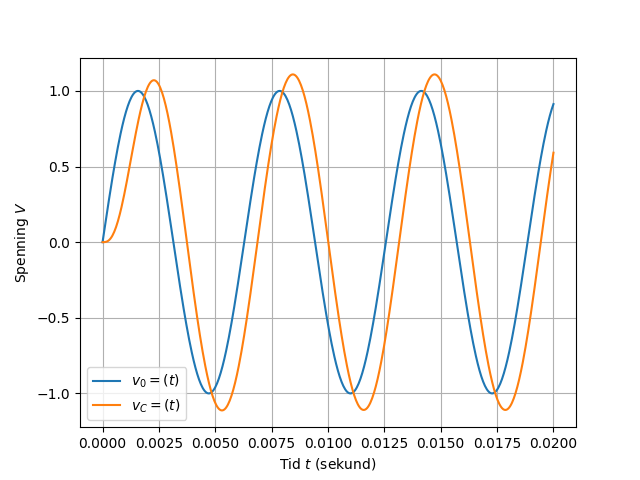

In [1]:
# LØSNING!
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
%matplotlib ipympl

# Generer inngangssignal
omega = 1000 # Vinkelfrekvens
t_stop = .02 # Varighet

t = np.linspace(0, t_stop, 501)  # Tidspunkt
v_0 = np.sin(omega*t) # Spenningspåtrykk v_0(t)

# Sett opp simulert RLC-krets
R = 10 # Motstand
L = 5e-3 # Spole
C = 5e-5 # Kondensator

numerator = [1/(L*C)]
denominator = [1, R/L, 1/(L*C)]
system = sig.TransferFunction(numerator, denominator)

# Utfør numerisk utregnign av kondensatorspenning v_C(t)
_, v_C, _ = sig.lsim(system, U = v_0, T = t) # Simulér den målte spenningen v_C(t)

# Vis plot av v_0(t) og v_C(t)
plt.plot(t, v_0, label=r"$v_0=(t)$")
plt.plot(t, v_C, label=r"$v_C=(t)$")
plt.grid(True)
plt.legend()
plt.xlabel("Tid $t$ (sekund)")
plt.ylabel("Spenning $V$")

#### Teorisvar:
* Utregning av $\left|H(j\omega)\right|$ for $\omega = 1000$:
    * Amplitude v_0(t): $A_0 = 1$V
    * Målt amplitude $v_C(t)$: $A_C \approx 1.11$ V
$$\left|H(j1000)\right| = \frac{A_C}{A_0} = 1.11$$
* Utregning av $\angle H(j\omega)$ for $\omega = 1000$:
    * Positivt nullkrysninstidspunkt $v_0(t)$: $ t_a = 18.85$ ms
    * Positivt nullkrysninstidspunkt $v_C(t)$: $ t_b = 19.44$ ms
$$
\begin{align}
\angle H(j1000) &= \omega \cdot \Delta t\\
&= 1000\cdot (t_a - t_b) \\
&= 1000\cdot (18.85 - 19.44)\cdot 10^{-3} \\
&= -0.59 \text{ rad} \\
&\approx -33.8^\circ 
\end{align}
$$

***
### Oppgave b)
* Gjenta målingene i oppgave ***a)*** for vinkelfrekvenser $\omega = 2000,\ 4000\ \&\ 8000$ rad/s.

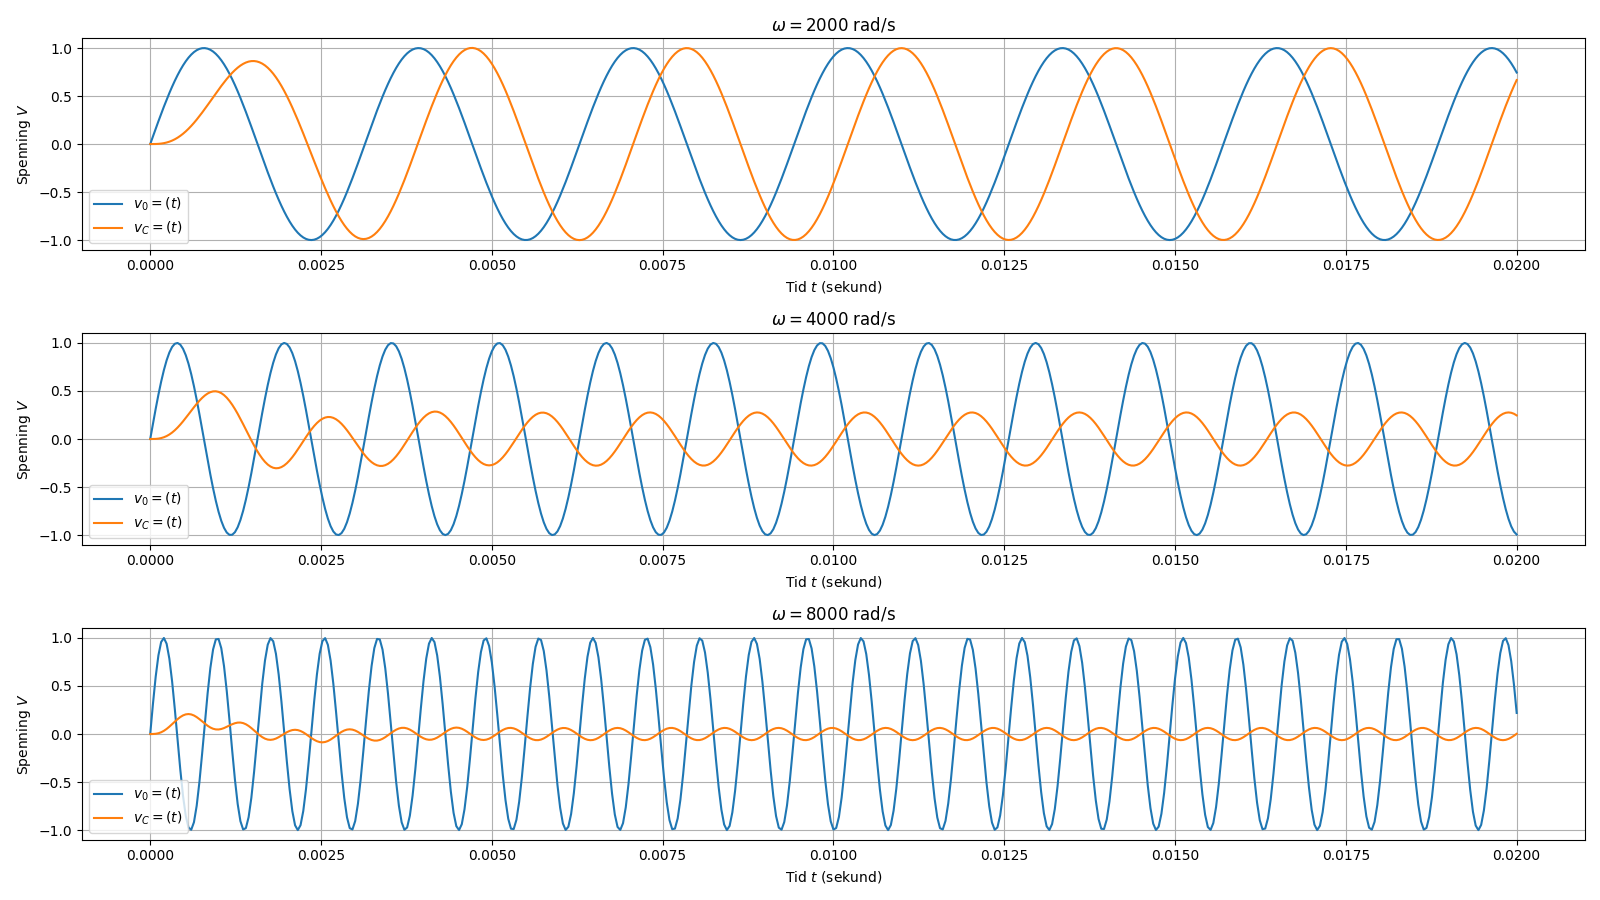

In [10]:
# LØSNING!
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
%matplotlib ipympl

# Sett opp simulert RLC-krets
R = 10 # Motstand
L = 5e-3 # Spole
C = 5e-5 # Kondensator

numerator = [1/(L*C)]
denominator = [1, R/L, 1/(L*C)]
system = sig.TransferFunction(numerator, denominator)

omega_list = [2000, 4000, 8000]

plt.figure(figsize=(16,9))

for i in range(len(omega_list)):
    plt.subplot(3,1,i+1)
    # Generer inngangssignal
    omega = omega_list[i] # Vinkelfrekvens
    t_stop = .02 # Varighet

    t = np.linspace(0, t_stop, 501)  # Tidspunkt
    v_0 = np.sin(omega*t) # Spenningspåtrykk v_0(t)

    # Utfør numerisk utregnign av kondensatorspenning v_C(t)
    _, v_C, _ = sig.lsim(system, U = v_0, T = t) # Simulér den målte spenningen v_C(t)

    # Vis plot av v_0(t) og v_C(t)
    plt.plot(t, v_0, label=r"$v_0=(t)$")
    plt.plot(t, v_C, label=r"$v_C=(t)$")
    plt.grid(True)
    plt.legend(loc="lower left")
    plt.xlabel("Tid $t$ (sekund)")
    plt.ylabel("Spenning $V$")
    plt.title(r"$\omega=%d$ rad/s"%(omega_list[i]))
plt.tight_layout()

#### Teorisvar $\omega = 2000$ rad/s:
* Utregning av $\left|H(j\omega)\right|$ for $\omega = 2000$:
    * Amplitude $v_0(t)$:  $A_0 = 1$V
    * Målt amplitude $v_C(t)$: $A_C \approx 1$ V
$$\left|H(j2000)\right| = \frac{A_C}{A_0} = 1$$
* Utregning av $\angle H(j\omega)$ for $\omega = 2000$:
    * Positivt nullkrysninstidspunktg $v_0(t)$: $ t_a = 18.85$ ms
    * Positivt nullkrysninstidspunkt $v_C(t)$: $ t_b = 19.63$ ms
$$
\begin{align}
\angle H(j2000) &= \omega \cdot \Delta t\\
&= 2000\cdot (t_a - t_b) \\
&= 2000\cdot (18.85 - 19.63)\cdot 10^{-3} \\
&= -1.59 \text{ rad} \\
&\approx -89.4^\circ 
\end{align}
$$

#### Teorisvar $\omega = 4000$ rad/s:
* Utregning av $\left|H(j\omega)\right|$ for $\omega = 4000$:
    * Amplitude v_0(t): $A_0 = 1$V
    * Målt amplitude $v_C(t)$: $A_C \approx 0.277$ V
$$\left|H(j4000)\right| = \frac{A_C}{A_0} = 0.277$$
* Utregning av $\angle H(j\omega)$ for $\omega = 4000$:
    * Positivt nullkrysninstidspunkt $v_0(t)$: $ t_a = 18.85$ ms
    * Positivt nullkrysninstidspunkt $v_C(t)$: $ t_b = 19.48$ ms
$$
\begin{align}
\angle H(j4000) &= \omega \cdot \Delta t\\
&= 4000\cdot (t_a - t_b) \\
&= 4000\cdot (18.85 - 19.48)\cdot 10^{-3} \\
&= -2.52 \text{ rad} \\
&\approx -144.4^\circ 
\end{align}
$$

#### Teorisvar $\omega = 8000$ rad/s:
* Utregning av $\left|H(j\omega)\right|$ for $\omega = 8000$:
    * Amplitude v_0(t): $A_0 = 1$V
    * Målt amplitude $v_C(t)$: $A_C \approx 0.0643$ V
$$\left|H(j8000)\right| = \frac{A_C}{A_0} =0.0643$$
* Utregning av $\angle H(j\omega)$ for $\omega = 8000$:
    * Positivt nullkrysninstidspunkt $v_0(t)$: $ t_a = 18.85$ ms
    * Positivt nullkrysninstidspunkt $v_C(t)$: $ t_b = 19.21$ ms
$$
\begin{align}
\angle H(j8000) &= \omega \cdot \Delta t\\
&= 8000\cdot (t_a - t_b) \\
&= 8000\cdot (18.85 - 19.21)\cdot 10^{-3} \\
&= -2.88 \text{ rad} \\
&\approx -165.0^\circ 
\end{align}
$$

***
### Oppgave c)
* Bruk python til å regne ut $\left|H(j\omega)\right|$ og $\angle H(j\omega) $ for $\omega \in \{1000, 2000, 4000, 8000\}$ rad/s ved hjelp av formeluttrykket til transferfunksjonen $H(s)$.
* Sammenlign de utregnede verdiene med det du målte i deloppgave **a)** og **b)**.

In [12]:
# Løsning!
omega_list = [1000, 2000, 4000, 8000]
# Sett opp simulert RLC-krets
R = 10 # Motstand
L = 5e-3 # Spole
C = 5e-5 # Kondensator

for w in omega_list:
    Hw = 1/(L*C)/((1j*w)**2+R/L*(1j*w) + 1/(L*C))
    mag = np.abs(Hw)
    phase = np.angle(Hw, deg=True)
    print(f"|H(j{w})| = {mag:.3f}")
    print(f"∠H(j{w}) = {phase:.1f} degrees")

|H(j1000)| = 1.109
∠H(j1000) = -33.7 degrees
|H(j2000)| = 1.000
∠H(j2000) = -90.0 degrees
|H(j4000)| = 0.277
∠H(j4000) = -146.3 degrees
|H(j8000)| = 0.064
∠H(j8000) = -165.1 degrees


#### Teorisvar:
Målingene stemmer godt overens med de teoretisk utregnede verdiene, med noen små unøyaktigeter.

***
### Oppgave d)
* Bruk Python sin funksjon [`scipy.signal.bode()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.bode.html) til å lage et bode-plot for den seriekoblede RLC-kretsen. Dataen bør visualiseres med funksjonen `semilogx` fra `matplotlib.pyplot` for å få korrekt logaritmisk skala langs fekvensaksen.
* Les av fase og magnitude ($\left|H(j\omega)\right|$) for frekvensene $\omega \in \{1000, 2000, 4000, 8000\}$ i bode-plottet, og sammenlign med resultatet fra deloppgave.
    * *NB! Husk at bode-plot viser magnitude i decibel (dB). Formelen for utregning av decibel er: $H_{dB} = 20\cdot \log_{10}\left(H\right)$*

Text(0.5, 0, 'Angular frequency (rad/s)')

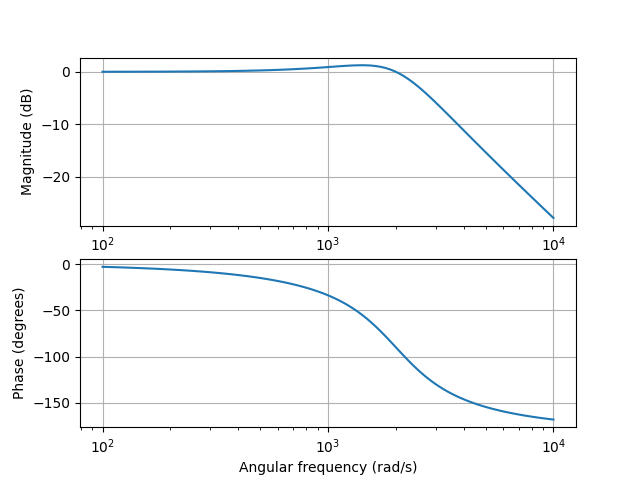

In [2]:
# Løsning!
w, mag, phase = sig.bode(system)

plt.figure()
plt.subplot(2,1,1)
plt.semilogx(w, mag)
plt.grid(True)
plt.ylabel("Magnitude (dB)")
plt.subplot(2,1,2)
plt.semilogx(w, phase)
plt.grid(True)
plt.ylabel("Phase (degrees)")
plt.xlabel("Angular frequency (rad/s)")

### Teorisvar: 

Avleste verdier for magnitude:
|Frekvens (rad/s)|Mag (dB)|Mag (lineær)|$$\text{Fase }^\circ$$|
|---|---|---|---|
|1000|0.95|$$10^{\frac{0.91}{20}} = 1.11$$ | -33.7|
|2000|0.00|$$10^{\frac{0.00}{20}} = 1.00$$ | -89.7|
|4000|-11.14|$$10^{\frac{11.14}{20}} = 0.277$$ | -146.4|
|8000|-23.82|$$10^{\frac{-23.82}{20}} = 0.0644$$ | -165.1|

* Avleste verdier fra bode-plottet korresponderer veldig godt med svarene fra deloppgave a) og b). 